# Analizando el threshold
Los modelos de clasificación no generan directamente clasificaciones binarias, sino **probabilidades de pertenencia a una clase**. Para convertir estas probabilidades en etiquetas binarias, se utiliza un **threshold** o umbral, generalmente fijado en **0.5 por defecto**. Mosificar este umbral afecta significativamente las métricas: un threshold más bajo aumenta la sensibilidad (más verdaderos positivos, pero también más falsos positivos), mientras que un threshold más alto incrementa la especificidad (menos falsos positivos, pero también menos verdaderos positivos). 

En sklearn, hay dos formas de obtener predicciones:
- _y_pred= predict(X)_, que proporciona clasificaciones binarias en base al threshold=0.5
- _y_pred= predict_proba(X)_, más realista y flexible, que propociona probabilidades. Proporcina la probabilidad de la **Clase 0, _y_pred[:,0]** y la probabilidad de la **Clase 1, _y_pred[:,1]**


Por lo tanto, es crucial elegir el umbral adecuado según el contexto y los objetivos del modelo.

## Ejemplo 2
Crear un modelo sencillo de regresión logística para la base de datos _Adult Income_, que contiene información demográfica de personas que se utiliza para predecir si ganan más o menos de 50.000$ anuales. Establecer el proceso de escalado pertinente para las variables numéricas y trabaja en una estructura tr/ts con un train del 80%.

In [4]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
df = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = df.data.features 
y = df.data.targets 
  
# X
print(X.head()) 
# y
print(y.head()) 

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  
   num
0    0
1    2
2    1
3    0
4    0


In [8]:
## Análisis rápido sobre las características de la base
print(f'Número de filas y columnas {X.shape}') # Mostrar la forma del DataFrame (número de filas y columnas)
print(f'Tipo de los datos {X.dtypes}') # Mostrar los tipos de datos de las columnas
print(f'Estadísticas descriptivas {X.describe()}') # Mostrar estadísticas descriptivas del DataFrame
print(f'Matriz de correlación {X.corr()}') # Calcular la matriz de correlación entre las características numéricas
print(f'Número de muestras por categoría {y.groupby(y.iloc[:, -1]).size()}') # Contar el número de muestras por categoría

Número de filas y columnas (303, 13)
Tipo de los datos age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object
Estadísticas descriptivas               age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000 

## OJO:
La variable objetivo toma 5 valores distintos, la binarizamos para poder proceder con procesos de clasificación conocidos.

In [3]:
## Por ejemplo: transformación vectorizada
import numpy as np

# Suponiendo que y tiene valores numéricos
y_bin = y.copy()  # Copiar el DataFrame original
y_bin[:] = np.where(y >= 1, 1, 0)
print(y_bin.head())



   num
0    0
1    1
2    1
3    0
4    0


In [13]:
# Establecer una semilla concreta (en este caso, 12345)
SEED = 12345

# Para aleatorización en Python
import random
random.seed(SEED)

# Para aleatorización en numpy
import numpy as np
np.random.seed(SEED)

In [15]:
print("Variables explicativas: ", X.columns)
print("Variable objetivo: ", y_bin.columns) 

Variables explicativas:  Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')
Variable objetivo:  Index(['num'], dtype='object')


In [17]:
import pandas as pd

# Ponemos X e y en el mismo df para poder analizar las variables, especialmente los missing, a la vez
df = pd.concat([X, y_bin], axis=1, ignore_index=True)
df.head

# Verificar cuántos valores missing hay por columna

print(df.isnull().sum())
# Verificar si el DataFrame tiene algún valor missing
print(df.isnull().any().any())
# Filtrar y mostrar las filas que tienen algún valor missing
print(df[df.isnull().any(axis=1)])

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    4
12    2
13    0
dtype: int64
True
     0   1   2    3    4   5   6    7   8    9   10   11   12  13
87   53   0   3  128  216   0   2  115   0  0.0   1  0.0  NaN   0
166  52   1   3  138  223   0   0  169   0  0.0   1  NaN  3.0   0
192  43   1   4  132  247   1   2  143   1  0.1   2  NaN  7.0   1
266  52   1   4  128  204   1   0  156   1  1.0   2  0.0  NaN   1
287  58   1   2  125  220   0   0  144   0  0.4   2  NaN  7.0   0
302  38   1   3  138  175   0   0  173   0  0.0   1  NaN  3.0   0


In [19]:
# hay pocos datos faltantes, los borramos
# Eliminar filas que contengan al menos un valor faltante sin modificar el conjunto original
#X_clean = X.dropna()

# Modificar el DataFrame original
df.dropna(inplace=True)
df.head

<bound method NDFrame.head of      0   1   2    3    4   5   6    7   8    9   10   11   12  13
0    63   1   1  145  233   1   2  150   0  2.3   3  0.0  6.0   0
1    67   1   4  160  286   0   2  108   1  1.5   2  3.0  3.0   1
2    67   1   4  120  229   0   2  129   1  2.6   2  2.0  7.0   1
3    37   1   3  130  250   0   0  187   0  3.5   3  0.0  3.0   0
4    41   0   2  130  204   0   2  172   0  1.4   1  0.0  3.0   0
..   ..  ..  ..  ...  ...  ..  ..  ...  ..  ...  ..  ...  ...  ..
297  57   0   4  140  241   0   0  123   1  0.2   2  0.0  7.0   1
298  45   1   1  110  264   0   0  132   0  1.2   2  0.0  7.0   1
299  68   1   4  144  193   1   0  141   0  3.4   2  2.0  7.0   1
300  57   1   4  130  131   0   0  115   1  1.2   2  1.0  7.0   1
301  57   0   2  130  236   0   2  174   0  0.0   2  1.0  3.0   1

[297 rows x 14 columns]>

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#una vez eliminados los missings, volvemos a coger X e y
X = df.drop(df.columns[-1], axis=1)
y = df.iloc[:, -1]

# Hacer la división tr/ts
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Definir el objeto para escalar las variables numéricas (todas en este caso) 
scaler = StandardScaler()

# Escalar cada parte por separado
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Definir el modelo de regresión, lo hacemos sin parámetros
model = LogisticRegression(random_state=SEED,max_iter=1000)

#Entrenar el modelo, usando sólo los datos de entrenamiento escalados y la variable binarizada como objetivo
model.fit(X_train_scaled, y_train)

#Obtener predicciones, usando sólo los datos de test escalados
y_pred = model.predict_proba(X_test_scaled)[:,1]

print(f'Las predicciones obtenidas son {y_pred[:5]}')


Las predicciones obtenidas son [0.43974251 0.08325256 0.48008995 0.86148666 0.83911764]


## OJO: 
Si las predicciones se obtienen como probabilidad, hay que binarizarlas antes de calcular las medidas de bondad de ajuste. 
Para ello, hay que aplicar un threshold. 

Sí se puede trabajar con probabilidades para calcular la curva ROC y el AUC, ya que el sistema escoge los thresholsd a utilizar.

In [24]:
from sklearn.metrics import roc_curve, auc
#roc_curve calcula las tasas fpr y tpr para distintos punto de corte, establecidos por el sistema dependiendo de los datos
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
print(f"Tasa de falsos positivos: {fpr[:5]}")
print(f"Tasa de verdaderos positivos: {tpr[:5]}")
print(f"Puntos de corte (thresholds): {thresholds[:5]}")

Tasa de falsos positivos: [0.         0.         0.         0.06451613 0.06451613]
Tasa de verdaderos positivos: [0.         0.03448276 0.37931034 0.37931034 0.5862069 ]
Puntos de corte (thresholds): [       inf 0.9930962  0.92525623 0.91196299 0.76993921]


## Solución
Para calcular el resto de medidas de bondad de ajuste, escoger threshold y binarizar las probabilidades

## ¿Qué umbral utilizar?
Si no hay ninguna especificación propia del problema, o se quiere tomar una decisión rápida, tras conocer _tpr_ y _fpr_, una opción es elegir el umbral en función del punto de equilibrio máximo (donde la distancia entre la curva ROC y la diagonal es mayor), aplicando el **índice de Youden: tpr - fpr**

In [27]:
import numpy as np

# Calcular el índice de Youden para cada umbral
youden_index = tpr - fpr

# Encontrar el umbral que maximiza el índice de Youden
best_threshold = thresholds[np.argmax(youden_index)]

print(f"Umbral óptimo según el índice de Youden: {best_threshold}")


Umbral óptimo según el índice de Youden: 0.2042282181271614


# IMPORTANTE!!!!
Las medidas de bondad de ajuste hay que calcularlas en **TEST**

Los elementos de la matriz de confusión son tn: 22; fp: 9; fn: 3 y tp: 26.


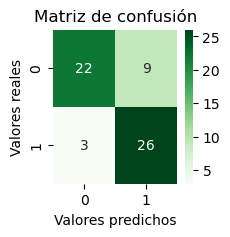

Accuracy: 0.8
Precisión: 0.7428571428571429
F1_score: 0.8125
Recall/sensibilidad: 0.896551724137931


In [35]:
threshold=best_threshold
y_pred_binary = (y_pred >= threshold).astype(int)

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, 
#matriz de confusión
cm = confusion_matrix(y_test, y_pred_binary)
tn, fp, fn, tp= cm[0][0], cm[0][1], cm[1][0], cm[1][1]     
print(f"Los elementos de la matriz de confusión son tn: {tn}; fp: {fp}; fn: {fn} y tp: {tp}.")


import matplotlib.pyplot as plt
import seaborn as sns
clases = ['0', '1']

# Crear un mapa de calor para mejorar la visualización
plt.figure(figsize=(2, 2))
sns.heatmap(cm, annot=True, cmap='Greens', fmt='g', xticklabels=clases, yticklabels=clases)
plt.xlabel('Valores predichos')
plt.ylabel('Valores reales')
plt.title('Matriz de confusión')
plt.show()
plt.close()

accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy}")

precision=precision_score(y_test, y_pred_binary)
print(f"Precisión: {precision}")

f1=f1_score(y_test, y_pred_binary)
print(f"F1_score: {f1}")

recall = recall_score(y_test, y_pred_binary)
print(f"Recall/sensibilidad: {recall}")

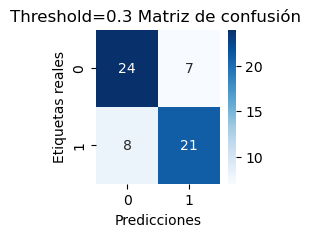

Accuracy: 0.75
Precisión: 0.75
F1_score: 0.7368421052631579
Recall/sensibilidad: 0.7241379310344828


/var/folders/yk/65m66v4j5_l_ppkvs0q7j9cw0000gn/T/ipykernel_3822/2074139134.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


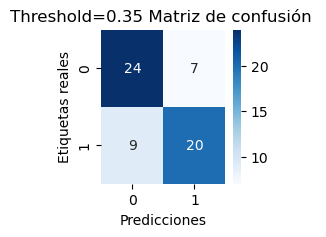

Accuracy: 0.7333333333333333
Precisión: 0.7407407407407407
F1_score: 0.7142857142857143
Recall/sensibilidad: 0.6896551724137931


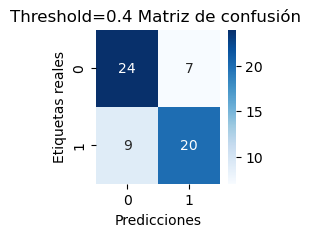

Accuracy: 0.7333333333333333
Precisión: 0.7407407407407407
F1_score: 0.7142857142857143
Recall/sensibilidad: 0.6896551724137931


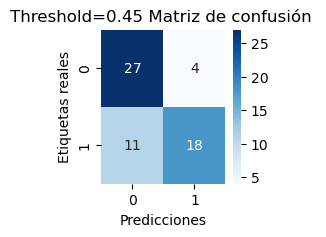

Accuracy: 0.75
Precisión: 0.8181818181818182
F1_score: 0.7058823529411765
Recall/sensibilidad: 0.6206896551724138


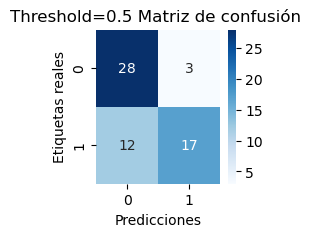

Accuracy: 0.75
Precisión: 0.85
F1_score: 0.6938775510204082
Recall/sensibilidad: 0.5862068965517241


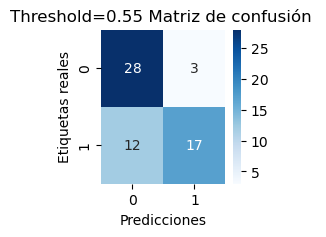

Accuracy: 0.75
Precisión: 0.85
F1_score: 0.6938775510204082
Recall/sensibilidad: 0.5862068965517241


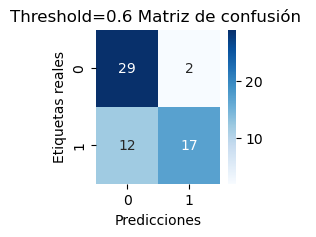

Accuracy: 0.7666666666666667
Precisión: 0.8947368421052632
F1_score: 0.7083333333333334
Recall/sensibilidad: 0.5862068965517241


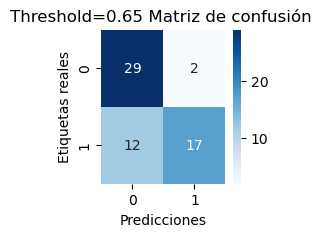

Accuracy: 0.7666666666666667
Precisión: 0.8947368421052632
F1_score: 0.7083333333333334
Recall/sensibilidad: 0.5862068965517241


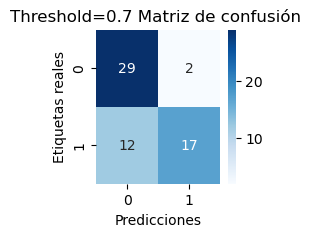

Accuracy: 0.7666666666666667
Precisión: 0.8947368421052632
F1_score: 0.7083333333333334
Recall/sensibilidad: 0.5862068965517241


In [37]:
 # Iterar a través de thresholds para comparar resultados
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
results_df = pd.DataFrame(columns=["FP", "FN", "TP", "TN","recall","precision","accuracy","f1","TH"])
for threshold in thresholds:
    y_pred_binary = (y_pred >= threshold).astype(int)
    clases = ['0', '1']
    cm = confusion_matrix(y_test, y_pred_binary)
    fp, fn, tp, tn = cm[0][1], cm[1][0], cm[1][1], cm[0][0]
 # Create a heatmap of the confusion matrix
    plt.figure(figsize=(2, 2))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=clases, yticklabels=clases)
    plt.xlabel('Predicciones')
    plt.ylabel('Etiquetas reales')
    plt.title('Threshold=' + str(threshold) + ' Matriz de confusión ')
    #si se quisieran guardar las imágenes
    #filename = 'TH=' + str(threshold) + ' Confusion Matrix ' + '.png'
    #filename = filename.replace("\n", "_").replace(" ", "_").replace(".", "") 
        
    plt.show()
    plt.close()

    accuracy = accuracy_score(y_test, y_pred_binary)
    print(f"Accuracy: {accuracy}")

    precision=precision_score(y_test, y_pred_binary)
    print(f"Precisión: {precision}")
    
    f1=f1_score(y_test, y_pred_binary)
    print(f"F1_score: {f1}")

    recall = recall_score(y_test, y_pred_binary)
    print(f"Recall/sensibilidad: {recall}")
    new_row = pd.DataFrame({
                "FP": [fp],
                "FN": [fn],
                "TP": [tp],
                "TN": [tn],
                "recall": [recall],
                "precision": [precision],
                "accuracy": [accuracy],
                "f1": [f1],                
                "TH": [threshold],
            })
      # Concatenar la nueva fila al DataFrame de resultados
    results_df = pd.concat([results_df, new_row], ignore_index=True)

## Representamos la evolución

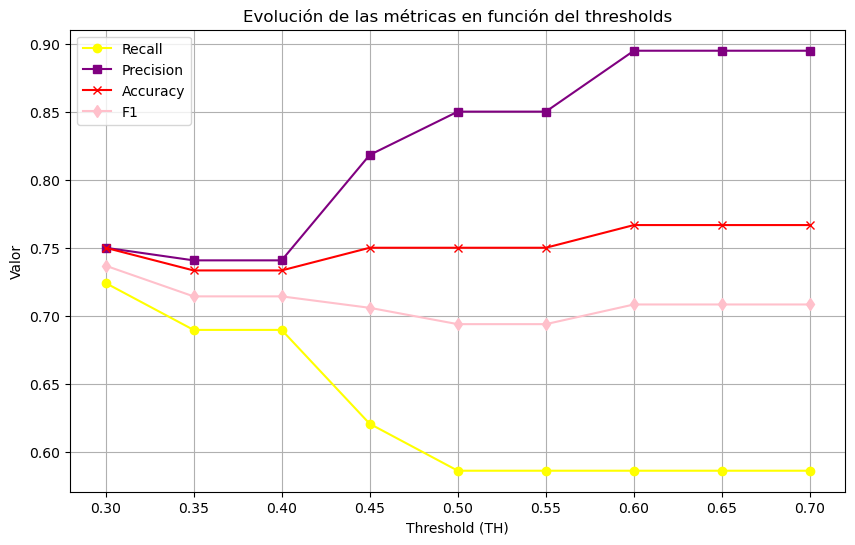

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 6))

# Graficar cada métrica con su respectiva coloración y marcador
plt.plot(results_df['TH'], results_df['recall'], label='Recall', color='yellow', marker='o')
plt.plot(results_df['TH'], results_df['precision'],label='Precision', color='purple', marker='s')
plt.plot(results_df['TH'], results_df['accuracy'], label='Accuracy', color='red', marker='x')
plt.plot(results_df['TH'], results_df['f1'], label='F1', color='pink', marker='d')

# Configuración de la gráfica
plt.title('Evolución de las métricas en función del thresholds')
plt.xlabel('Threshold (TH)')
plt.ylabel('Valor')
plt.legend()

# Mostrar la cuadrícula
plt.grid(True)

# Mostrar la gráfica
plt.show()